# Generative Neural Networks

Model architectures underlying LLMs

When experimenting with Markov models, we observed the trade-off between the context length, i.e., how many tokens we “looked back”, and the ability to generate novel text. Longer context lengths allowed for more coherent text generation, but at some point the model was just recreating the training data verbatim (there was only one “next token” for any given context). Today we will explore *Transformers*, a neural network architecture designed to capture the long-range dependencies so important to semantic understanding, while still generating novel sequences.

Let’s load the GPT2 model with the ability to output attention weights so we can visualize its inner workings.

In [ ]:
import torch # Common imports for Pytorch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForCausalLM
checkpoint = "openai-community/gpt2"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
# Use slower eager attention to enable attention outputs
model = AutoModelForCausalLM.from_pretrained(checkpoint, attn_implementation="eager", output_attentions=True)
model.eval();  # Put model in evaluation mode

Consider the sentence “The dog ran up the street and barked loudly.”, which might be tokenized as follows (recall the ‘Ġ’ encodes a space in this tokenizer). What relationships between tokens would be important to capture for a model to generate new text?

In [ ]:
inputs = tokenizer("The dog ran up the street and barked loudly.")
tokenizer.convert_ids_to_tokens(inputs["input_ids"])

## (Decoder-only) Transformer Architecture

The Transformer architecture, introduced in the paper [“Attention is All You Need”](https://arxiv.org/abs/1706.03762) by Vaswani et al. in 2017, has become a (the?) foundational neural network architecture for natural language processing (NLP) tasks and increasingly for computer vision and other domains too. Previously, most sequence-to-sequence models, such as for machine translation or text generation, used recurrent neural networks (RNNs) to process input sequences. But RNNs are inherently sequential; many computational steps are required to propagate “information” between distant elements, i.e., to capture the “long-range dependencies” we identified above. Transformers implement a *self-attention* mechanism to efficiently capture the relationships between all elements in a sequence, even those at “long distance”, in parallel.

The original application was for machine translation, and so “Attention is All You Need” proposed an encoder-decoder architecture (the encoder processed the source language, while the decoder generated the target language). Models such as GPT2, our example here, only use the decoder portion for generative language modeling tasks while other models use different subsets (e.g., just the encoder portion) of the full Transformer architecture. Today we will focus on GPT2 and decoder-only models for next-token prediction, but we note that many variants of the Transformer architecture exist.

> **Further exploration**
>
> We encourage you to check out [Transformer Explainer](https://poloclub.github.io/transformer-explainer/), a fantastic interactive visualization of the entire GPT2 model architecture, including embeddings, positional encodings, multi-head self-attention, feed-forward layers, etc., and the [“Illustrated Transformer”](https://jalammar.github.io/illustrated-transformer/) and [“Illustrated GPT2”](https://jalammar.github.io/illustrated-gpt2/) blog posts.

<figure id="fig-gpt-block-diagram">
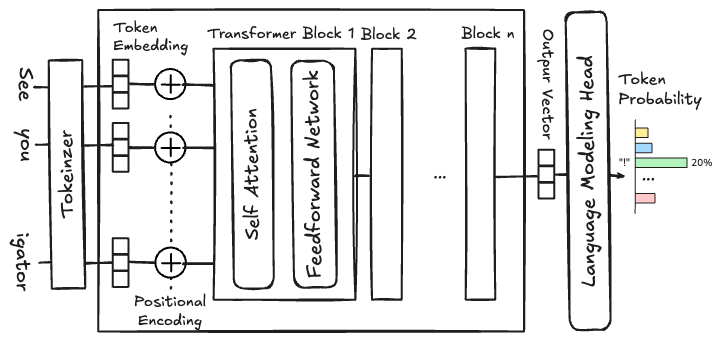
<figcaption>Figure 1: Block diagram of decoder-only LLM, like GPT2, with multiple transformer blocks</figcaption>
</figure>

<a href="#fig-gpt-block-diagram" class="quarto-xref">Figure 1</a>, above, shows a block diagram of the GPT2 architecture. Notice that tokens are processed in parallel, i.e., the entire input sequence is processed at once, rather than sequentially as in RNNs. This is a key feature of Transformer architectures that enables efficient training and inference on modern compute hardware. Let’s follow the data flow through the model:

1.  The input text is tokenized as we discussed previously,
2.  then the tokens are converted to embeddings (dense vector representations of size $d_{\text{model}}$), and
3.  combined with positional encodings that provide information about the position of each token in the sequence.
4.  The resulting representations are then passed through multiple layers of Transformer blocks, each consisting of a multi-head self-attention layer followed by a feed-forward neural network (similar to those we discussed previously).
5.  Finally, a linear layer maps the output of the last Transformer block to the vocabulary size to produce logits for predicting the next token.

The positional encoding are required to enable the parallel processing of tokens. The Transformer architecture doesn’t inherently encode the order of the tokens (each token undergoes the same transformations) so positional encodings are added to the token embeddings to provide that ordering information. Without positional encodings, the model would treat all tokens as if they were at the same position in the input sequence, i.e., “The dog bit the man” and “The man bit the dog” would be processed identically. Positional encodings can be fixed (e.g., using sinusoidal functions) or learned during training (the case for GPT2).

Each of those components plays an important role in the overall architecture (and are worthy of detailed investigation on their own); but for today, we will focus on the self-attention mechanism, and its role in propagating information between different tokens in a sequence.

## Self Attention

Self-attention is a mechanism that allows each token in a sequence to “attend” to (i.e., consider and incorporate information from) other tokens in the same sequence when producing its output representation. This is implemented by computing attention weights that quantify the importance of each token relative to others. The attention weights are then used to compute a weighted sum of the token representations, allowing each token to incorporate information from other relevant tokens in the sequence.

The original paper defined the scaled dot-product attention mechanism as:

$$
\text{Attention}(Q,K,V) = \text{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right)V
$$

where $Q$ (queries), $K$ (keys), and $V$ (values) are all derived from the input token representations via learned linear transformations, and $d_k$ is the dimensionality of the key vectors (used for scaling). The softmax function ensures that the attention weights sum to 1, effectively creating a probability distribution over the tokens.

Specifically:

-   The queries $\boldsymbol{Q}=\boldsymbol{x} \times \boldsymbol{W_q}$ are “attended from”, i.e., what we are trying to find relevant information for.
-   The keys $\boldsymbol{K}=\boldsymbol{x} \times \boldsymbol{W_k}$ are “attended to”, i.e., which tokens might provide relevant information for a given query.
-   The values $\boldsymbol{V}=\boldsymbol{x} \times \boldsymbol{W_v}$ will be aggregated together, weighted by the relevance computed from the queries and keys.

where $\boldsymbol{x}$ is a matrix of embeddings (or the output of the previous transformer layer) for all tokens in the sequence. These operations are expressed as matrices because they are computed in parallel for all tokens in the sequence.

One analogy for this process<span class="column-margin margin-aside">Adapted from [“Illustrated GPT2”](https://jalammar.github.io/illustrated-gpt2/)</span>, is searching through a file cabinet. The query, represents exactly that, the information we are looking for (say written on a sticky note), the keys are the labels on the folders we are looking through, and the values of the are information in the folders we pull out to combine into the final result, weighted by the relevance of the keys to the query (the folder labels to the stick note).

### Interlude: Multi-Head Attention

We would describe the above as a single attention “head”. To enable more expressive power, the Transformer architecture often uses multiple attention heads in parallel, each with its own set of learned transformations for queries, keys, and values. This allows the model to capture different types of relationships and interactions between tokens simultaneously. For example, one “head” might focus on grammatical structure (subject-verb agreement), another on semantic meaning (what entities are related), another on sentiment (is this positive or negative?), and another on temporal relationships (what happened when?). The outputs of all attention heads are concatenated and linearly transformed to produce the final output representation.

$$
\begin{align*}
\text{MultiHead}(Q,K,V) & = \text{Concat}(\text{head}_1,...,\text{head}_h)W_o \\
\text{where}\; \text{head}_i & = \text{Attention}(Q_i, K_i, V_i)
\end{align*}
$$

where $W_q^i$, $W_k^i$, and $W_v^i$ are all $\in \mathbb{R}^{d_{\text{model}} \times d_{q,k,v}}$, i.e., all are matrices of size $d_{\text{model}} \times d_{q,k,v}$ (the model dimension by the identical query, key or value dimension), and $W_o \in \mathbb{R}^{hd_v \times d_{\text{model}}}$ where $h$ is the number of heads.

### Visualizing Attention

The notion of the query and key likely seem abstract at this point. Fortunately, we can readily visualize the attentions weights learned by different heads in different layers of our GPT2 model to get a better sense of how self-attention is working in practice. Specifically we will visualize the results of the softmax operation in the attention formula above, i.e., $\text{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right)$. Recall these are the weights used to compute the weighted combination of $V$ for each token.

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

def _format_special_chars(tokens):
    """Return sequence of tokens with special characters replaced"""
    return [t.replace('Ġ', ' ') for t in tokens]

def plot_attention(attentions, inputs, layer=0, head=0, **kwargs):
    """Plot the attentions attention weights, labeled with tokens, for a specific layer and head."""
    tokens = _format_special_chars(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))
    att = attentions[layer][0, head, :, :].detach().numpy()
    ax = sns.heatmap(att, xticklabels=tokens, yticklabels=tokens, **kwargs)
    ax.set(title=f"Attentions Layer {layer} Head {head}", xlabel="Attends to", ylabel="Query")
    return ax

Consider the following input sequence “The girl and the boy walked home. She”. <span class="column-margin margin-aside">These examples are adapted from @vigAttentionVis2019</span>. What are the relevant tokens that “She” should “attend” to understand this sentence? We interpret “She” in the second sentence as referring to the “girl” in the first sentence and so would expect that the attention weights (for some layer and head) would reflect this relationship. And indeed we can see in the attention weights for layer 5, head 10, the token “She” (last row) attends strongly to “girl” (second column).

In [ ]:
inputs = tokenizer("The girl and the boy walked home. She", return_tensors="pt")
output = model(**inputs)
# output.attentions is (layers) length tuple of (batch_size, num_heads, seq_len, seq_len) tensors
# containing attention weights after the attention softmax, used to compute the weighted average in
# self-attention heads.
plot_attention(output.attentions, inputs, layer=5, head=10)
plt.show()

Let’s trace through the attention calculation for the token “She” in this attention head. “She” is the query, i.e., $q_8$. Each element in that corresponding row of the attention weights (row at index 8 in the heatmap) corresponds to the dot product between the query vector for “She” and the key vectors for “She” and all preceding tokens in the sequence (e.g., $k_0$ for “The”, $k_1$ for “girl”, …), scaled and normalized via softmax. The resulting distribution is used to compute a weighted sum of the value vectors to produce $z_8$, the output representation for “She” from this attention head. Specifically for this head, $z_8=0.25v_0 + 0.41v_1 + \ldots$, i.e., primarily incorporates information from $t_0$ and $t_1$, “The” and “girl”.

<figure id="fig-attention-qkv">
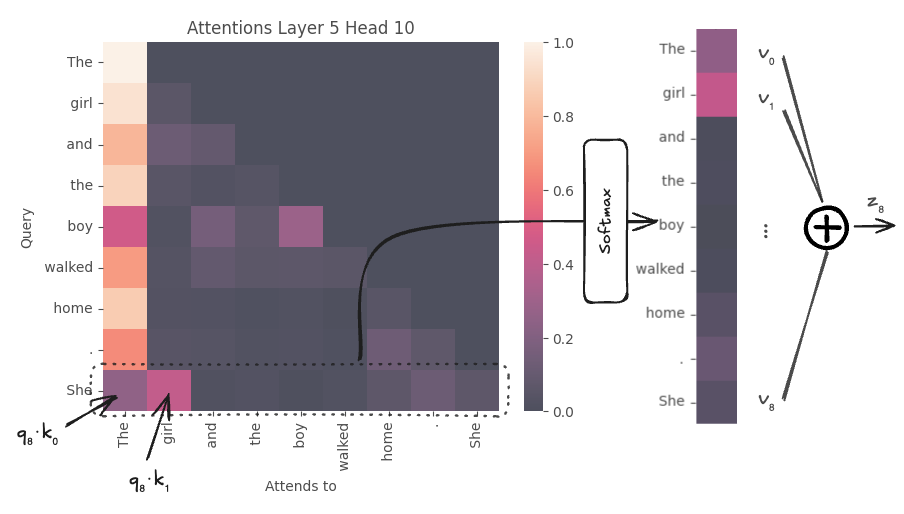
<figcaption>Figure 2: Tracing attention calculation for a particular token</figcaption>
</figure>

In [ ]:
output.attentions[5][0, 10, 8, :].detach()

Contrast that with the attention map when we replace “She” with “He” in the start of the second sentence.

> **What token(s) would you expect “He” to strongly attend to? (Try answering before expanding)**
>
> We would expect “He” to strongly attend to “boy” in the first sentence. And indeed that is what we see in the attention weights the same head with the different input.

In [ ]:
inputs = tokenizer("The girl and the boy walked home. He", return_tensors="pt")
output = model(**inputs)
plot_attention(output.attentions, inputs, layer=5, head=10)
plt.show()

Not all heads in all layers will show this behavior. Different layers and heads learn to focus on different aspects of the input sequence. Some heads may focus on syntactic relationships, while others may capture semantic relationships or positional information. This particular head seems to have learned gendered pronoun resolution. (And if we re-trained the model, this particular head, i.e., head 10 in layer 5, might learn very different attention patterns).

We can use [BertViz](https://github.com/jessevig/bertviz) to explore the entire model (“model view”) and interactively explore individual layers and heads like we did above (“head view”). To look at a single layer (click on the colors to show/hide specific heads):

In [ ]:
from bertviz import head_view, model_view

# Interactively view all layers and heads, defaulting to the same shown above
head_view(output.attentions, tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]), layer=5, heads=[10])

or the entire model:

In [ ]:
model_view(output.attentions, tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))

Notice that for some heads, tokens attend to themselves, in others, each token appears to attend to the previous token (e.g, layer 4, head 11) and many other relationships.

> **Why does the first token capture so much attention?**
>
> One noticeable pattern is that in many heads, tokens attend strongly to the very first token in the sequence (the “The” token in this case). This is a known pattern in large-language models, termed an “attention sink”, that has been extensively studied, but is not yet fully understood. These attention sinks seem to arise “naturally” during training, suggesting that they serve some useful purpose.

### How is attention computed in parallel?

Recall we expressed the Attention operation in terms of matrices. All transformations are computed in parallel for all tokens in the sequence via matrix multiplication. Consider for example, computing $\boldsymbol{V}=\boldsymbol{x} \times \boldsymbol{W_v}$. Here $\boldsymbol{x}$ is a matrix of size $n \times d_{\text{model}}$ where $n$ is the number of tokens, i.e., each row corresponds to the embedding (or output of the previous layer) for a single token. $\boldsymbol{W_v}$ is a matrix of size $d_{\text{model}} \times d_v$, where $d_v$ is the dimensionality of the value vectors. The resulting matrix $\boldsymbol{V}$ is of size $n \times d_v$, i.e., each row corresponds to the value vector for a single token. These matrix operations are efficient to compute, in parallel, on modern hardware (e.g., GPUs, TPUs), especially hardware with dedicated “tensor” cores (i.e., dedicated functional units for matrix multiplications).

<figure>
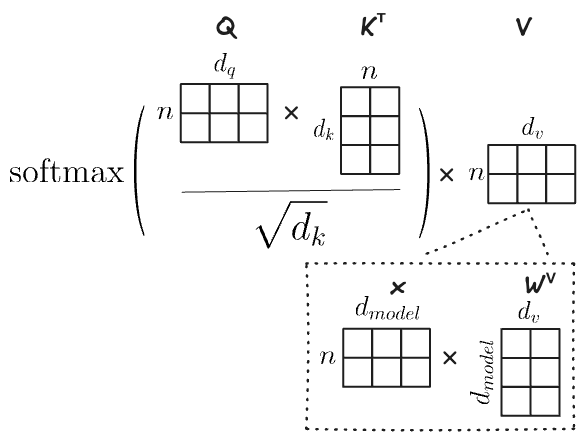
<figcaption aria-hidden="true">Attention as a matrix computation</figcaption>
</figure>

These matrix operations also point to one of the key challenges for scaling Transformers. Computing $QK^T$ requires computing the dot product between all pairs of tokens in the sequence, i.e., has a computational complexity that scales quadratically with the sequence length (specifically $\mathcal{O}(n^2d_k)$). Memory consumptions similarly scales quadratically with sequencing length for training and linearly for inference. While GPT2 has a context length (maximum sequence length) of 1024 tokens, more recent models have context lengths on the order of 100,000 to even 2 million tokens. Scaling to such long contexts requires specialized architectures and optimizations.

### ❓ We made a big deal about non-linearity before, where is it here?

We noted before that non-linear activation functions are essential for neural networks to learn complex functions. But we described many of the transformations e.g., computing the queries, keys, and values, as linear operations. So where is the non-linearity in the Transformer architecture? The Transformer architecture includes non-linearity in the softmax operation used to compute the attention weights and the feed-forward neural network layers in each transformer block. The softmax function is a non-linear activation function that transforms the raw attention scores (the dot products between queries and keys) into a probability distribution over the tokens. The feed-forward neural network layers that follow the multi-head attention layer within each Transformer block typically use non-linear activation functions like ReLU (Rectified Linear Unit) or GELU (Gaussian Error Linear Unit), just like the neural networks we discussed previously.

### Causal Masking (or why the upper triangle is zero)

Careful observers might have noticed that the upper right triangle of the attention weights are 0, i.e., tokens can only attend to themselves and preceding tokens, not future tokens. Those entries are purposely masked, termed *causal masking*. Doing so is essential for training autoregressive models like GPT2 that generate text one token at a time. Causal masking ensures that the model does not have access to future tokens when predicting the next token. During training, the model receives the full sequence as input, and simultaneously predicts each token, i.e., $p(t_1|\text{The})$, $p(t_2|\text{The},\text{girl})$, etc., We can then compute the loss over all tokens in the sequence in parallel, i.e., compute the error between $p(t_1|\text{The})$ and “girl”, between $p(t_2|\text{The},\text{girl})$ and “and”, and so on. Causal masking ensures that the model cannot “cheat” by looking ahead at future tokens when making predictions.

## What is encoded in the model parameters?

When considering Markov models outputs, we noted that for sufficient context lengths, the model would simply reproduce training data verbatim. But that text was not actually stored somewhere in the model (i.e., in a variable or data structure), rather the training data was encoded as next token probabilities, i.e., $P(t_i | t_{i-1}. \ldots, t_1)$. The same is true for GPT2, just with many more parameters and a much larger training dataset (40 GB of text data from the Internet). That is recurring patterns in the training data, i.e., recurring patterns in society (as reflected in Internet text), will be encoded in the model parameters. Consider the “The doctor asked the nurse a question. She”. What “attends to” pattern do you expect GPT2 learned for “She”? What if we replaced “She” with “He”?

In [ ]:
# Plot multiple attention maps side-by-side for comparison (with a shared colorbar)
fig, ax = plt.subplots(1, 3, figsize=(8, 4), gridspec_kw={'width_ratios':[1,1,0.05]}, layout='compressed')

inputs = tokenizer("The doctor asked the nurse a question. She", return_tensors="pt")
output = model(**inputs)
plot_attention(output.attentions, inputs, layer=5, head=10, ax=ax[0], cbar=False, vmin=0, vmax=1)
ax[0].set(title=None, ylabel=None, xlabel=None)

inputs = tokenizer("The doctor asked the nurse a question. He", return_tensors="pt")
output = model(**inputs)
plot_attention(output.attentions, inputs, layer=5, head=10, ax=ax[1], vmin=0, vmax=1, cbar_ax=ax[2])
ax[1].set(title=None, ylabel=None, xlabel=None)

fig.suptitle("Attentions Layer 5 Head 10")
fig.supylabel("Query")
fig.supxlabel("Attends to")

plt.show()

Notice that the model has learned gendered associations. “She” attends strongly to “nurse”, while “He” attends strongly to “doctor”. It is not that the developer’s explicitly programmed these associations into the model; rather, the model learned these associations from its training data. That training data incorporates past (and current) asymmetric gender distributions in those professions, societal stereotypes, and more as reflected in Internet text. Specifically, we would expect there are many more examples of “doctor” being referred to as “he” and “nurse” being referred to as “she” online. And the model reflects those patterns back to us in the parameters it learns and the text it generates. When we talk about biases in LLMs (our next topic), this is one example of what we are talking about. These models are only as “neutral” as the data they are trained on.

## How do we get to 124 million parameters?

We previously noted that GPT2 small has approximately 124 million parameters (specifically just referring to the core model, not including the head for predicting the next token). Let’s derive that number from first principles, based on the architecture described in the [GPT2 paper](@radfordGPT22019) as interpreted through the [Illustrated GPT-2](https://jalammar.github.io/illustrated-gpt2/) blog post. This tally is approximate as some implementation details may differ, but it should be close.

In [ ]:
context_size = 1024  # Context window size for GPT-2 small
d_model = 768        # Model dimension for GPT-2 small
num_heads = 12       # Number of attention heads per layer
num_layers = 12      # Number of transformer layers

# Single transformer layer
qkv_parameters = 3 * (d_model * d_model / num_heads + d_model / num_heads) * num_heads  # W_q, W_k, W_v weights and biases
wo_parameters = d_model * d_model + d_model  # W_o weights and biases
mlp_parameters = (d_model * 4 * d_model + 4 * d_model) + (4 * d_model * d_model + d_model)  # Two linear layers in MLP with intermediate size 4*d_model
norm_parmeters = 2 * (d_model + d_model)  # LayerNorm parameters (gamma and beta)

transfomer_layer_parameters = qkv_parameters + wo_parameters + mlp_parameters + norm_parmeters
transformer_parameters = transfomer_layer_parameters * num_layers

embedding_parameters = tokenizer.vocab_size * d_model  # Token embeddings
position_embedding_parameters = context_size * d_model  # Positional embeddings
final_norm_parameters = (d_model + d_model)  # Final LayerNorm parameters

gpt2_model_parameters = transformer_parameters + embedding_parameters + position_embedding_parameters + final_norm_parameters
next_token_head_parameters = d_model * tokenizer.vocab_size  # Final linear layer to vocab size (no bias)

total_parameters = gpt2_model_parameters + next_token_head_parameters
total_parameters, gpt2_model_parameters, next_token_head_parameters

Those estimates should generally match the actual number of parameters in the loaded model:

In [ ]:
from torchinfo import summary
summary(model)